# Exploratory Data Analysis and Feature Engineering
## Life Expectancy Dataset

This project performs:
- Dataset understanding
- Data quality checking
- Missing-value analysis
- Duplicate detection
- Validity and range checking
- Univariate analysis
- Bivariate analysis
- Correlation analysis
- Outlier analysis
- Data cleaning
- Feature engineering
- Final validation

## Importing Libraries

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load the dataset

In [51]:
df = pd.read_csv("../Dataset/Life Expectancy Data.csv")

### Data Samples

In [52]:
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [53]:
df.sample(5)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
1168,Hungary,2001,Developed,72.3,185.0,1,13.18,7.601092,NaN,20,...,99.0,7.11,99.0,0.1,527.85364,1187576.0,2.2,2.2,0.769,14.2
952,Gabon,2009,Developing,61.7,31.0,2,8.64,52.310863,79.0,0,...,74.0,3.43,76.0,8.0,763.66223,1586754.0,6.7,6.5,0.652,12.4
388,Bulgaria,2011,Developed,73.7,144.0,1,10.67,875.149519,96.0,157,...,95.0,6.88,95.0,0.1,7813.83499,7348328.0,2.0,2.0,0.775,14.2
2407,South Africa,2001,Developing,56.0,429.0,52,7.38,365.258572,72.0,1166,...,71.0,8.31,71.0,24.0,2681.78100,45312937.0,15.4,18.1,0.629,13.0
616,Congo,2007,Developing,58.2,354.0,8,2.75,0.000000,64.0,84,...,71.0,2.54,72.0,5.0,NaN,NaN,8.5,8.2,0.517,9.8


### Dataset Information

In [54]:
print(df.shape)
print("Rows: ",df.shape[0])
print("Columns: ",df.shape[1])

(2938, 22)
Rows:  2938
Columns:  22


#### The dataset contains 2938 rows and 22 columns

In [55]:
df.size

64636

In [56]:
df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='str')

In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

#### This identifies: * data types   * number of non-null values  * numerical columns  * categorical columns

In [58]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


#### This gives: * mean * standard deviation * minimum * quartiles * maximum

In [59]:
df.describe(include=["object","str"])

,Country,Status
count,2938,2938
unique,193,2
top,Afghanistan,Developing
freq,16,2426


#### This shows the number of unique categories and the most frequent category for each categorical feature.

### Missing Values

In [60]:
missing = pd.DataFrame({"Missing_Count": df.isnull().sum(), "Missing_Percentage": (df.isnull().sum() / len(df)) * 100})
missing = missing.sort_values(by="Missing_Percentage", ascending=False)
missing

,Missing_Count,Missing_Percentage
Population,652,22.191967
Hepatitis B,553,18.822328
GDP,448,15.248468
Total expenditure,226,7.692308
Alcohol,194,6.603131
Income composition of resources,167,5.684139
Schooling,163,5.547992
thinness 5-9 years,34,1.157250
thinness 1-19 years,34,1.157250
BMI,34,1.157250


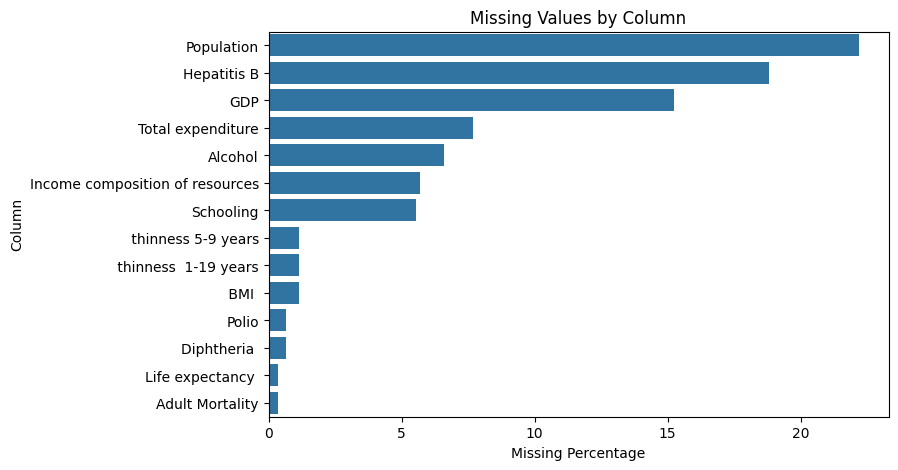

In [61]:
missing_plot = missing[missing["Missing_Count"] > 0]
plt.figure(figsize=(8, 5))
sns.barplot(x=missing_plot["Missing_Percentage"], y=missing_plot.index)
plt.title("Missing Values by Column")
plt.xlabel("Missing Percentage")
plt.ylabel("Column")
plt.show()

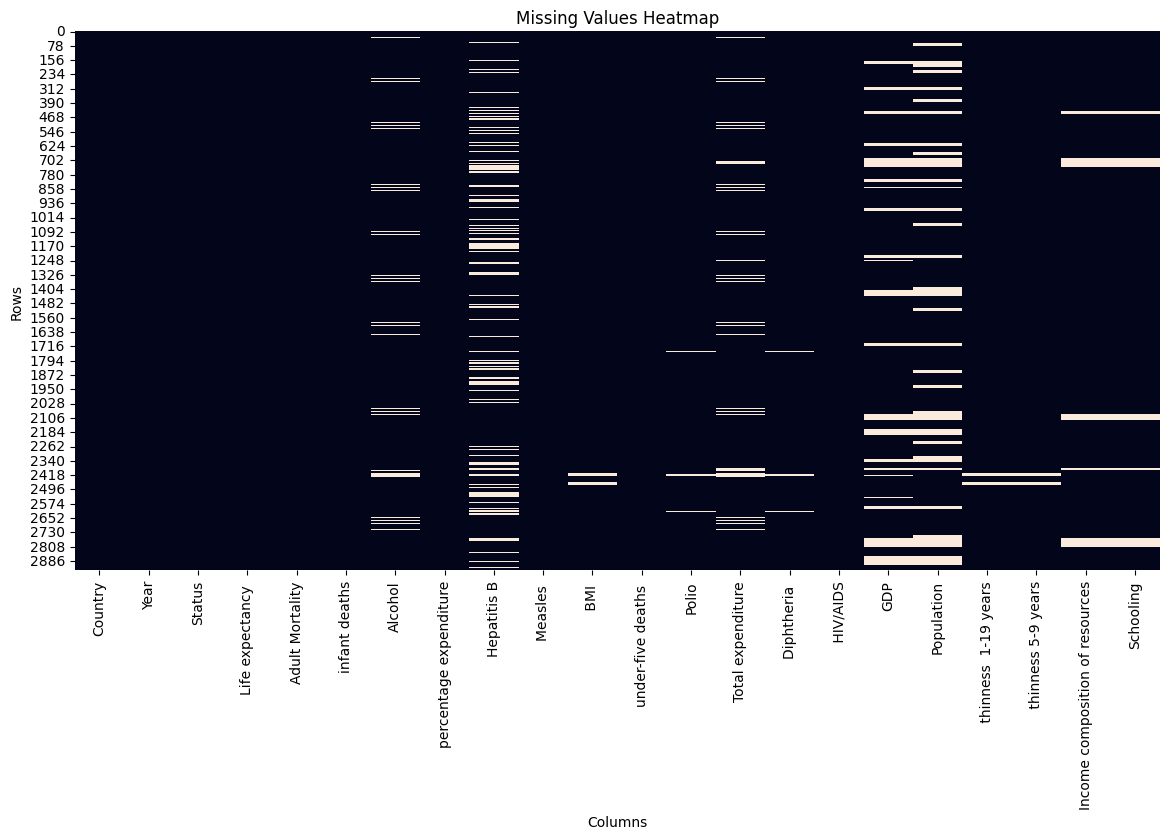

In [62]:
plt.figure(figsize=(14, 7))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

#### The heatmap makes it easier to see which columns contain missing data.

### Duplicate values

In [63]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


### Cleaning Columns Names

In [64]:
df.columns = (df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("/", "_").str.replace("-", "_").str.replace(r"_+", "_", 
                                                                                                                               regex=True))

In [65]:
df.columns

Index(['country', 'year', 'status', 'life_expectancy', 'adult_mortality',
       'infant_deaths', 'alcohol', 'percentage_expenditure', 'hepatitis_b',
       'measles', 'bmi', 'under_five_deaths', 'polio', 'total_expenditure',
       'diphtheria', 'hiv_aids', 'gdp', 'population', 'thinness_1_19_years',
       'thinness_5_9_years', 'income_composition_of_resources', 'schooling'],
      dtype='str')

### Unique Values

In [66]:
df["country"].nunique()

193

#### The dataset have 193 different countries

In [67]:
df["year"].unique()

array([2015, 2014, 2013, 2012, 2011, 2010, 2009, 2008, 2007, 2006, 2005,
       2004, 2003, 2002, 2001, 2000])

#### Data is from 2000 to 2015

In [68]:
df["status"].value_counts()

status
Developing    2426
Developed      512
Name: count, dtype: int64

### Numerical Values

In [69]:
numeric_columns = df.select_dtypes(include=np.number).columns
numeric_columns

Index(['year', 'life_expectancy', 'adult_mortality', 'infant_deaths',
       'alcohol', 'percentage_expenditure', 'hepatitis_b', 'measles', 'bmi',
       'under_five_deaths', 'polio', 'total_expenditure', 'diphtheria',
       'hiv_aids', 'gdp', 'population', 'thinness_1_19_years',
       'thinness_5_9_years', 'income_composition_of_resources', 'schooling'],
      dtype='str')

In [70]:
negative_values = (df[numeric_columns] < 0).sum()
negative_values[negative_values > 0]

Series([], dtype: int64)

In [71]:
zero_values = (df[numeric_columns] == 0).sum()
zero_values[zero_values > 0].sort_values(ascending=False)

measles                            983
infant_deaths                      848
under_five_deaths                  785
percentage_expenditure             611
income_composition_of_resources    130
schooling                           28
dtype: int64

In [72]:
zero_as_missing = ["bmi", "gdp", "population"]
for column in zero_as_missing:
    df[column] = df[column].replace(0, np.nan)

In [73]:
df[zero_as_missing].isnull().sum()

bmi            34
gdp           448
population    652
dtype: int64

In [74]:
print(df["year"].min())
print(df["year"].max())

2000
2015


In [75]:
percentage_columns = ["hepatitis_b", "polio", "diphtheria"]
for column in percentage_columns:
    print(column, "min =", df[column].min(), "max =", df[column].max())

hepatitis_b min = 1.0 max = 99.0
polio min = 3.0 max = 99.0
diphtheria min = 2.0 max = 99.0


In [76]:
df["income_composition_of_resources"].describe()

count    2771.000000
mean        0.627551
std         0.210904
min         0.000000
25%         0.493000
50%         0.677000
75%         0.779000
max         0.948000
Name: income_composition_of_resources, dtype: float64

In [77]:
df["bmi"].describe()

count    2904.000000
mean       38.321247
std        20.044034
min         1.000000
25%        19.300000
50%        43.500000
75%        56.200000
max        87.300000
Name: bmi, dtype: float64

In [78]:
df["population"].describe()

count    2.286000e+03
mean     1.275338e+07
std      6.101210e+07
min      3.400000e+01
25%      1.957932e+05
50%      1.386542e+06
75%      7.420359e+06
max      1.293859e+09
Name: population, dtype: float64

In [79]:
df["gdp"].describe()

count      2490.000000
mean       7483.158469
std       14270.169342
min           1.681350
25%         463.935626
50%        1766.947595
75%        5910.806335
max      119172.741800
Name: gdp, dtype: float64

### Missing values handling

In [80]:
df = df.dropna(subset=["life_expectancy"]).copy()
numeric_predictors = df.select_dtypes(include=np.number).columns.drop("life_expectancy")
for column in numeric_predictors:
    df[column] = df[column].fillna(df[column].median())

In [81]:
categorical_columns = df.select_dtypes(include=["object","str"]).columns
for column in categorical_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].mode()[0])

In [82]:
df.isnull().sum().sort_values(ascending=False)
print("Total missing values:",df.isnull().sum().sum())

Total missing values: 0


In [83]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


### Outliers

In [84]:
numeric_columns = df.select_dtypes(include=np.number).columns
outlier_summary = []
for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_limit) | (df[column] > upper_limit)]
    outlier_summary.append([column, len(outliers), round((len(outliers) / len(df)) * 100, 2), lower_limit, upper_limit])
outlier_summary = pd.DataFrame(outlier_summary,
    columns=["Column", "Outlier Count", "Outlier Percentage", "Lower Limit", "Upper Limit"])
outlier_summary

,Column,Outlier Count,Outlier Percentage,Lower Limit,Upper Limit
0,year,0,0.00,1.992500e+03,2.022500e+03
1,life_expectancy,10,0.34,4.420000e+01,9.460000e+01
2,adult_mortality,82,2.80,-1.570000e+02,4.590000e+02
3,infant_deaths,315,10.76,-3.300000e+01,5.500000e+01
4,alcohol,3,0.10,-8.331250e+00,1.683875e+01
5,percentage_expenditure,388,13.25,-6.517866e+02,1.099255e+03
6,hepatitis_b,320,10.93,6.100000e+01,1.170000e+02
7,measles,542,18.51,-5.433750e+02,9.056250e+02
8,bmi,0,0.00,-3.565000e+01,1.111500e+02
9,under_five_deaths,394,13.46,-4.200000e+01,7.000000e+01


In [85]:
columns_to_cap = [
    "infant_deaths",
    "under_five_deaths",
    "gdp",
    "population",
    "hiv_aids",
    "measles"
]

In [86]:
for column in columns_to_cap:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower_limit, upper=upper_limit)

In [87]:
outlier_summary_after = []
for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_limit) | (df[column] > upper_limit)]
    outlier_summary_after.append([column, len(outliers)])
pd.DataFrame(outlier_summary_after, columns=["Column", "Remaining Outliers"])

,Column,Remaining Outliers
0,year,0
1,life_expectancy,10
2,adult_mortality,82
3,infant_deaths,0
4,alcohol,3
5,percentage_expenditure,388
6,hepatitis_b,320
7,measles,0
8,bmi,0
9,under_five_deaths,0


In [88]:
important_numeric = [
    "life_expectancy",
    "adult_mortality",
    "infant_deaths",
    "alcohol",
    "bmi",
    "under_five_deaths",
    "hiv_aids",
    "gdp",
    "population",
    "schooling"
]

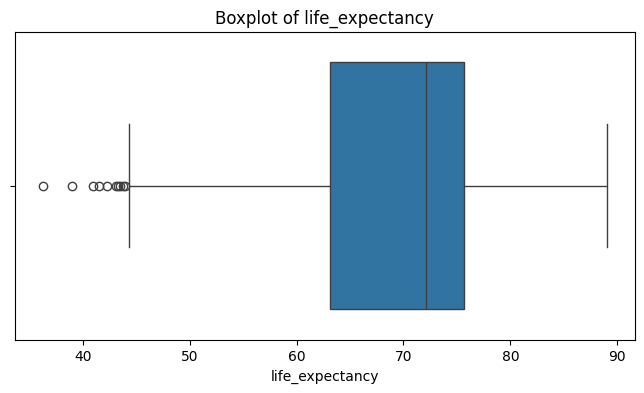

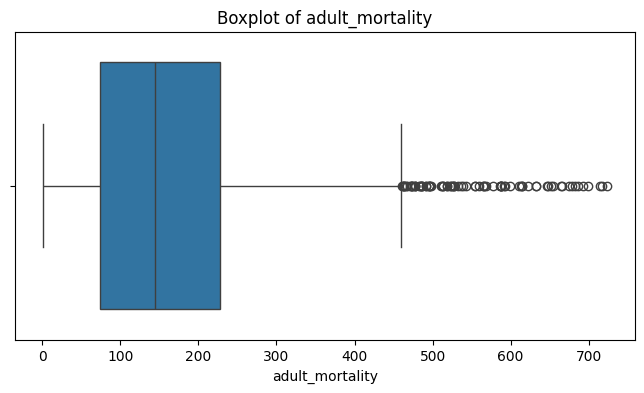

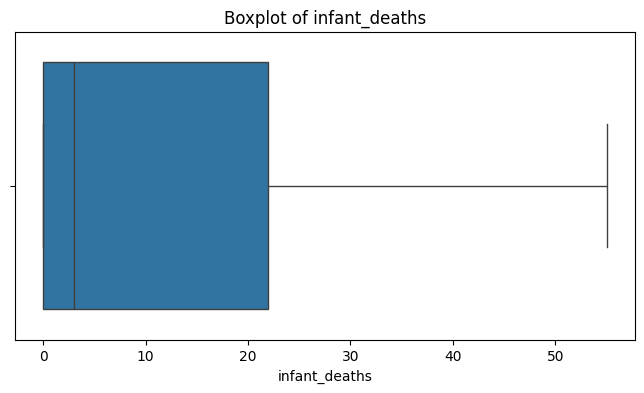

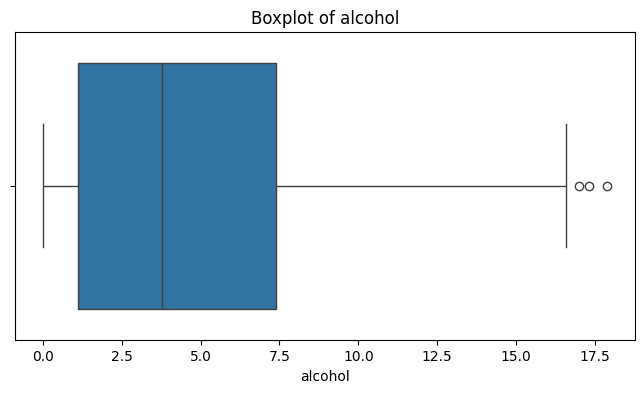

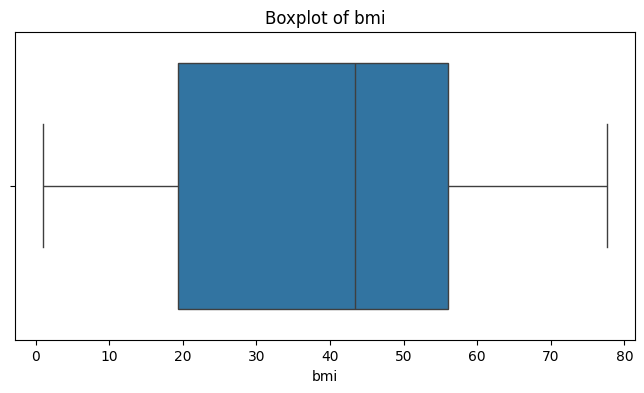

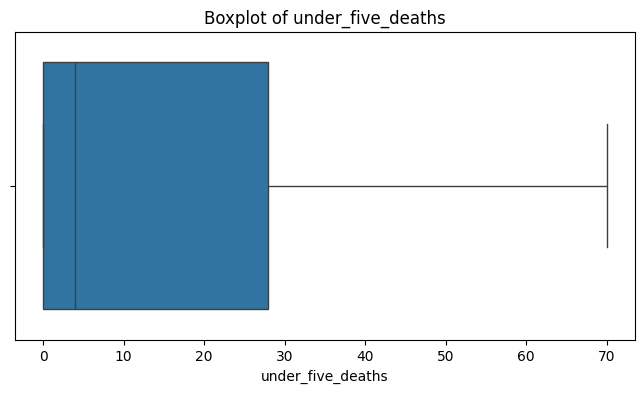

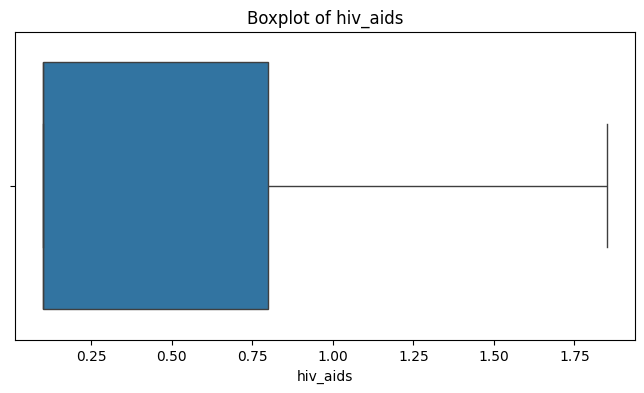

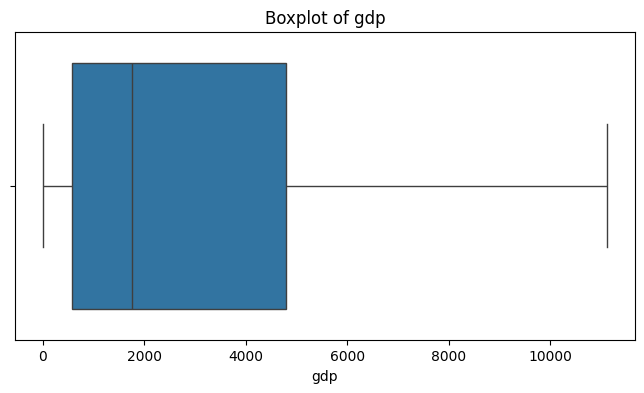

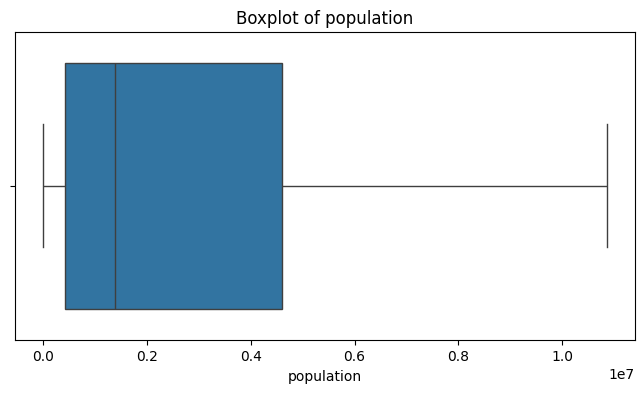

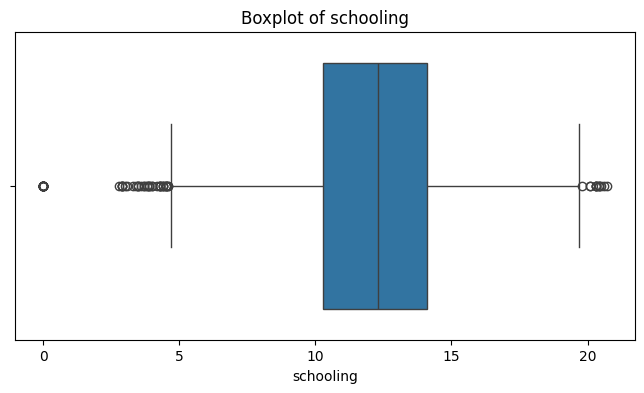

In [89]:
for column in important_numeric:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.show()

#### Missing-value insight
The target `life_expectancy` is not imputed. Its missing rows are removed because artificial target values would affect regression results. Missing predictor values are filled using the median for numerical variables and mode for categorical variables.

## EDA After Data Cleaning

### Distribution of Numerical Features


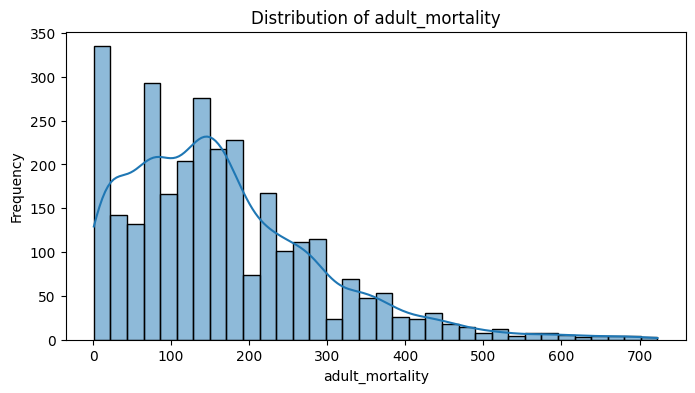

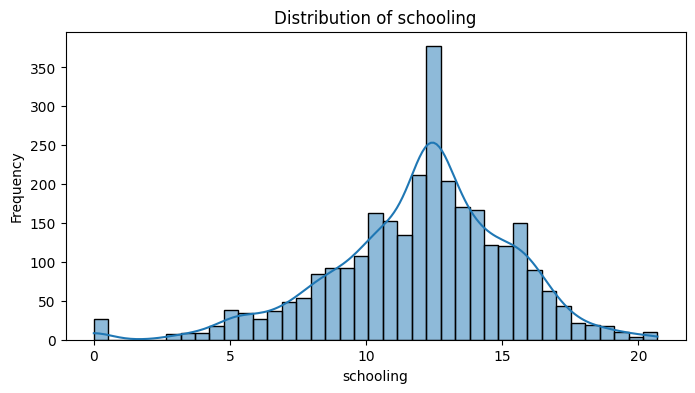

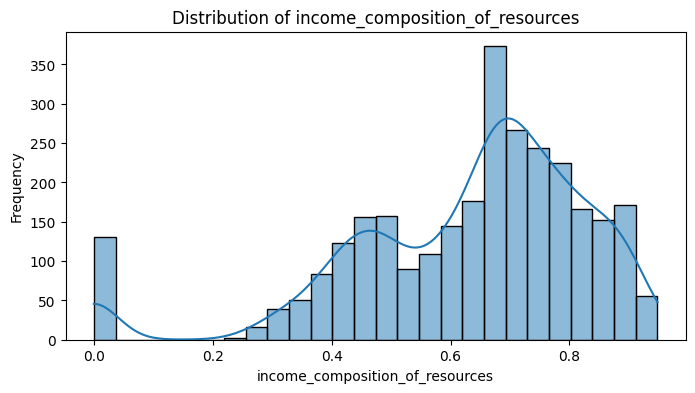

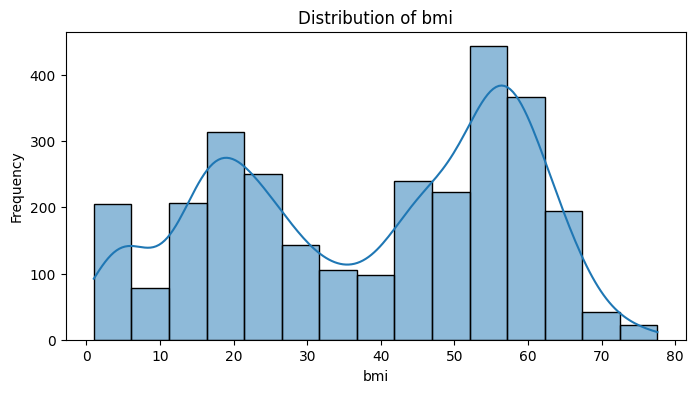

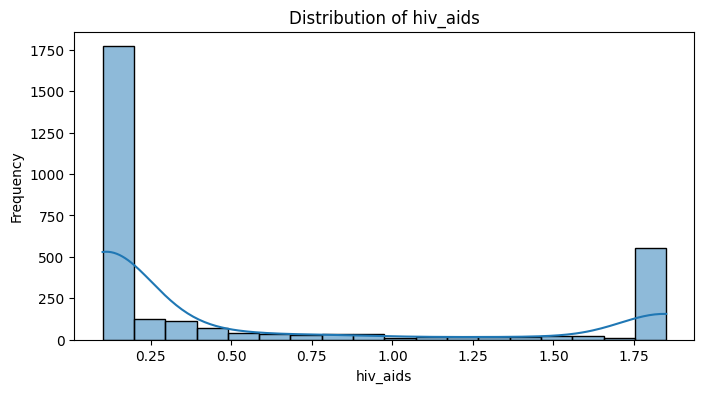

In [90]:
distribution_columns = [
    "adult_mortality",
    "schooling",
    "income_composition_of_resources",
    "bmi",
    "hiv_aids"
]
for column in distribution_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[column], kde=True)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()


Adult mortality and HIV/AIDS are strongly right-skewed, while schooling and income composition are more concentrated. The distributions show why extreme-value handling is important for some predictors.


### Categorical EDA: Country Status


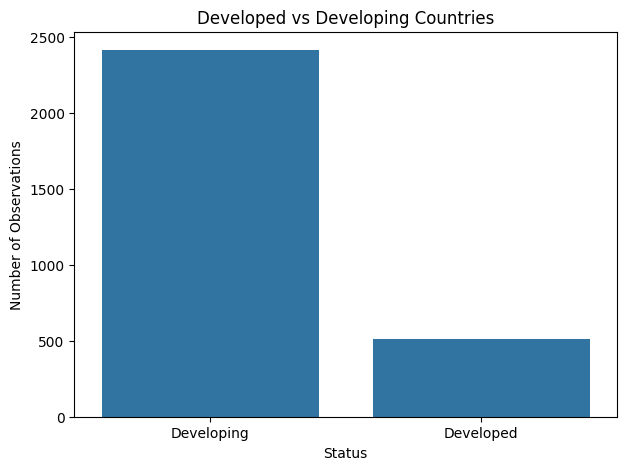

In [91]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="status")
plt.title("Developed vs Developing Countries")
plt.xlabel("Status")
plt.ylabel("Number of Observations")
plt.show()

The dataset contains substantially more observations from developing countries than developed countries, so status groups are not equally represented.

### Life Expectancy by Status


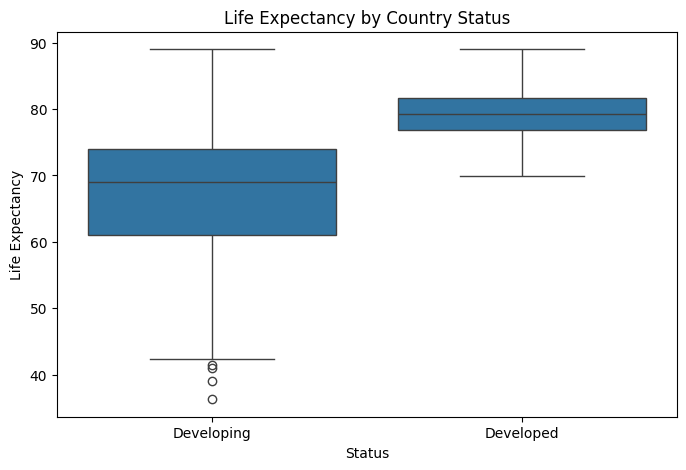

In [92]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="status", y="life_expectancy")
plt.title("Life Expectancy by Country Status")
plt.xlabel("Status")
plt.ylabel("Life Expectancy")
plt.show()

Developed-country observations generally have higher life expectancy than developing-country observations, with the boxplot also showing the spread and overlap between the groups.


### Average Life Expectancy Over Time


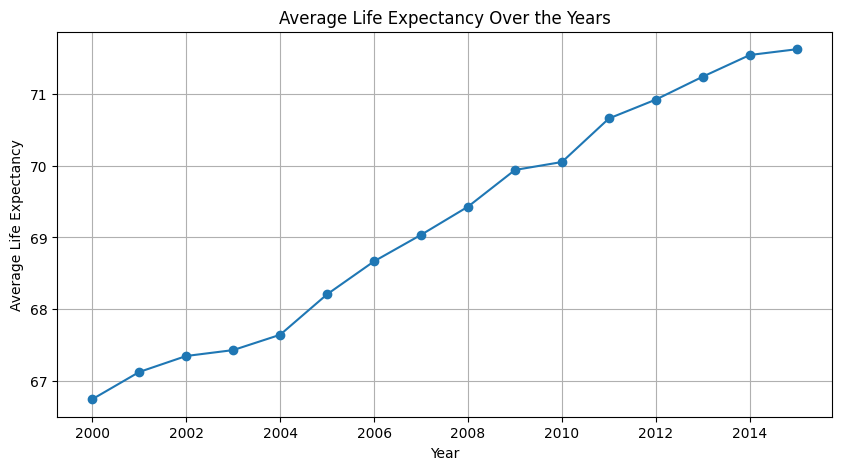

In [93]:
yearly_life_expectancy = df.groupby("year")["life_expectancy"].mean()
plt.figure(figsize=(10, 5))
plt.plot(yearly_life_expectancy.index, yearly_life_expectancy.values, marker="o")
plt.title("Average Life Expectancy Over the Years")
plt.xlabel("Year")
plt.ylabel("Average Life Expectancy")
plt.grid(True)
plt.show()

 The average life expectancy shows the overall time trend from 2000 to 2015 and helps identify whether the target generally improved or declined over the study period.


### Schooling vs Life Expectancy


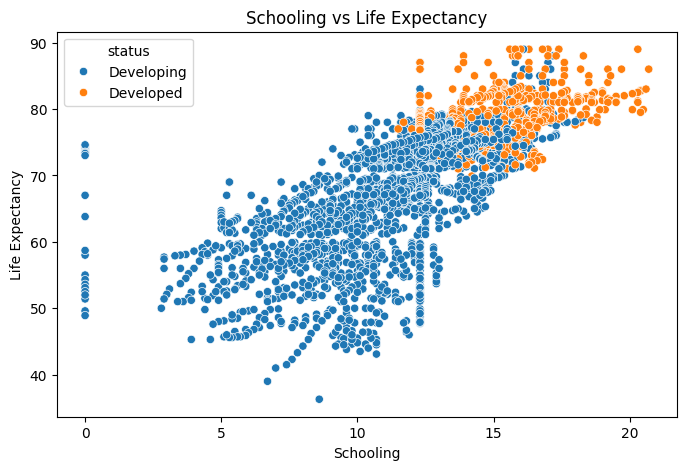

In [94]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="schooling", y="life_expectancy", hue="status")
plt.title("Schooling vs Life Expectancy")
plt.xlabel("Schooling")
plt.ylabel("Life Expectancy")
plt.show()

 The relationship is clearly positive: observations with higher schooling tend to have higher life expectancy. This is also consistent with the strong positive correlation found later.


### Adult Mortality vs Life Expectancy


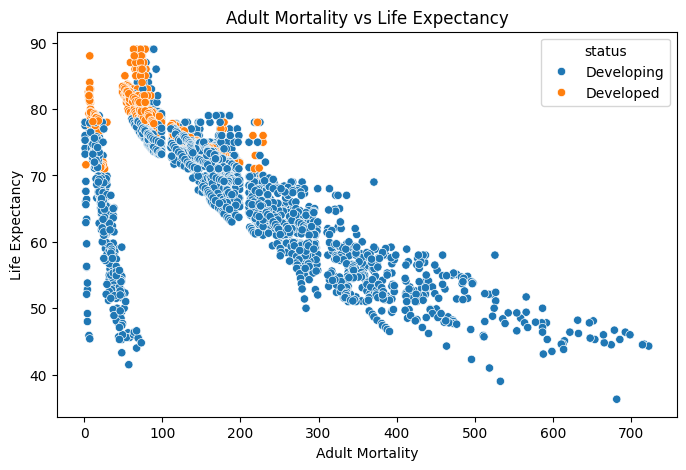

In [95]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="adult_mortality", y="life_expectancy", hue="status")
plt.title("Adult Mortality vs Life Expectancy")
plt.xlabel("Adult Mortality")
plt.ylabel("Life Expectancy")
plt.show()


 The relationship is strongly negative: higher adult mortality is generally associated with lower life expectancy. This is one of the most important relationships in the dataset.


### Correlation Heatmap


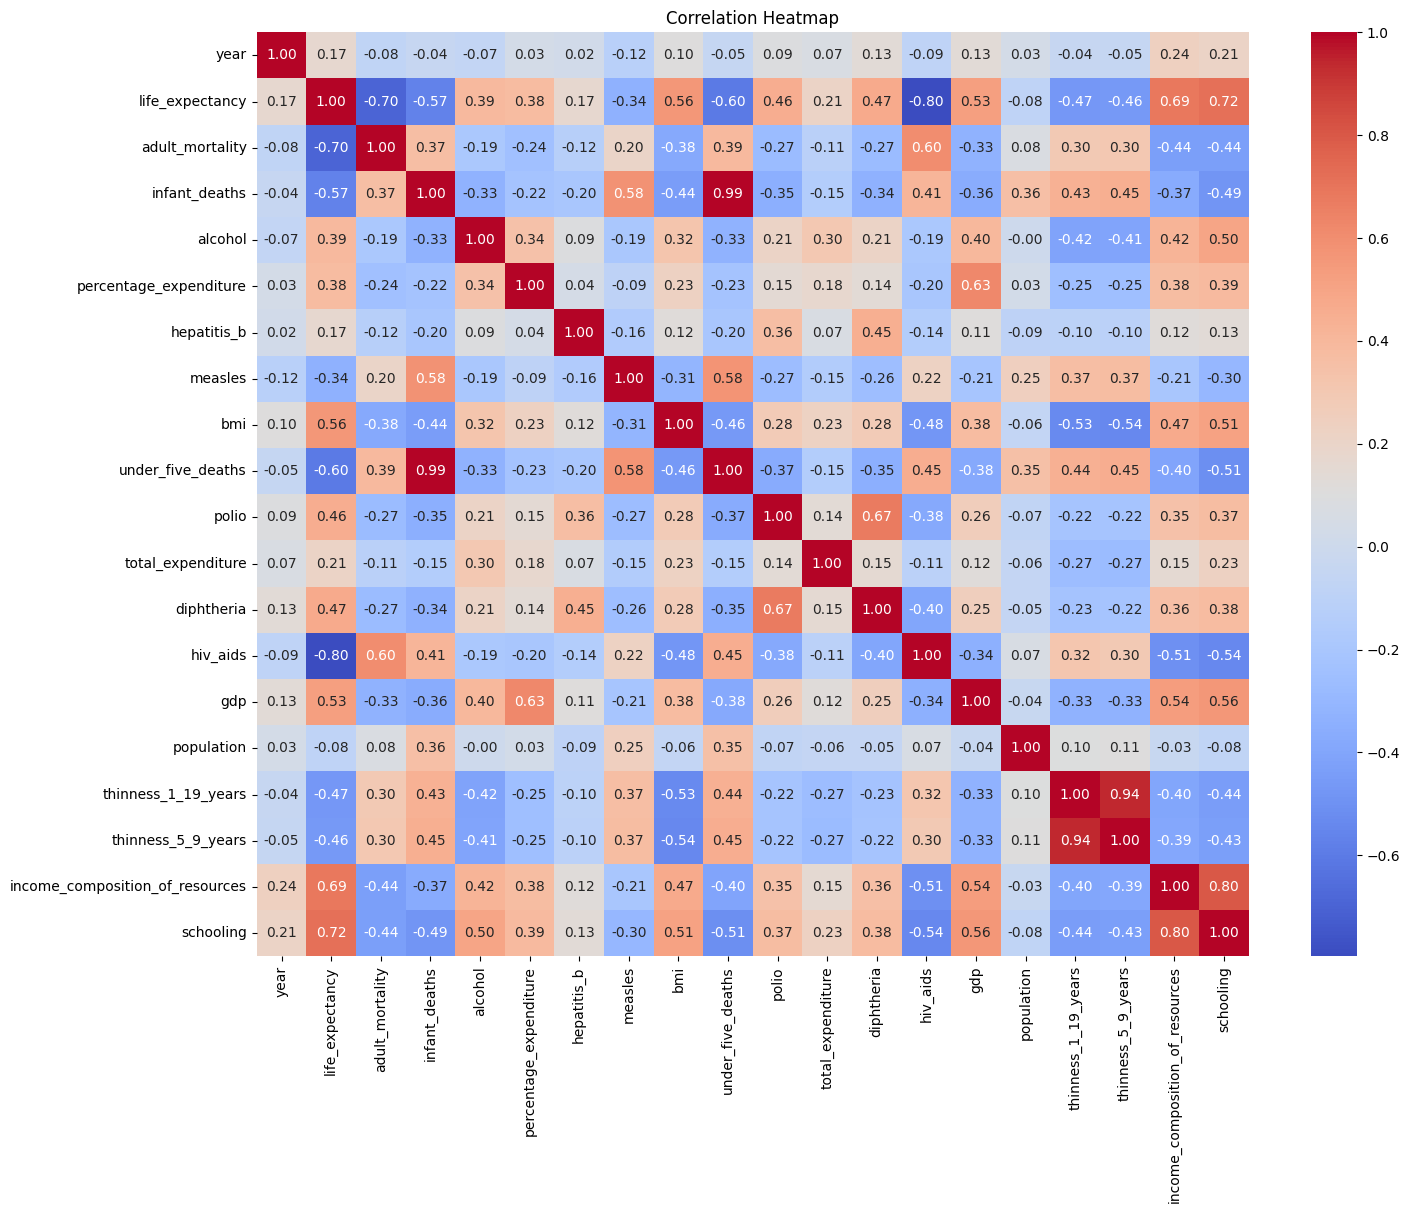

In [96]:
correlation = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(16, 12))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


The heatmap summarizes relationships among numerical variables. Schooling and income composition have strong positive relationships with life expectancy, while adult mortality and HIV/AIDS have strong negative relationships.


### Correlation with Life Expectancy


In [97]:
target_correlation = (df.select_dtypes(include=np.number) .corr()["life_expectancy"] .sort_values(ascending=False))
target_correlation

life_expectancy                    1.000000
schooling                          0.717314
income_composition_of_resources    0.688591
bmi                                0.558888
gdp                                0.526333
diphtheria                         0.473268
polio                              0.459458
alcohol                            0.390674
percentage_expenditure             0.381864
total_expenditure                  0.209588
hepatitis_b                        0.171255
year                               0.170033
population                        -0.082479
measles                           -0.336055
thinness_5_9_years                -0.462645
thinness_1_19_years               -0.467859
infant_deaths                     -0.566139
under_five_deaths                 -0.603594
adult_mortality                   -0.696359
hiv_aids                          -0.796137
Name: life_expectancy, dtype: float64

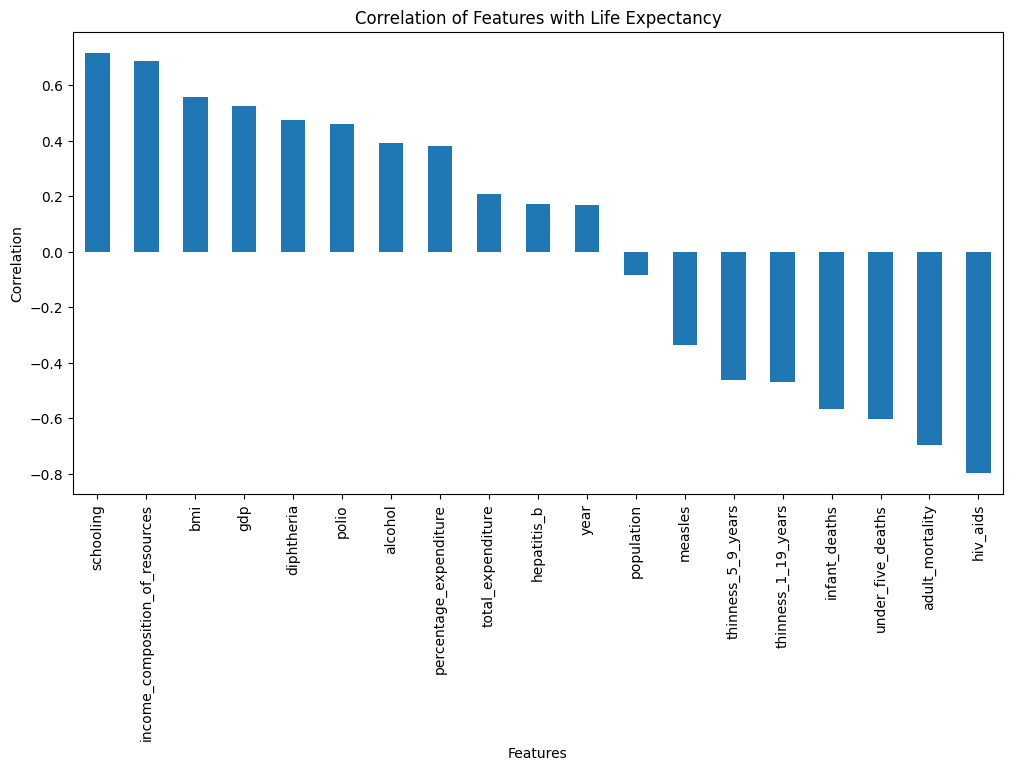

In [98]:
target_correlation.drop("life_expectancy").plot(kind="bar", figsize=(12, 6))
plt.title("Correlation of Features with Life Expectancy")
plt.xlabel("Features")
plt.ylabel("Correlation")
plt.xticks(rotation=90)
plt.show()

 Schooling and income composition are among the strongest positive correlates of life expectancy, while adult mortality and HIV/AIDS are among the strongest negative correlates.


## Feature Engineering


In [99]:
df["average_immunization"] = df[["hepatitis_b", "polio", "diphtheria"]].mean(axis=1)
df["total_child_deaths"] = (df["infant_deaths"] + df["under_five_deaths"])
df["average_thinness"] = df[["thinness_1_19_years", "thinness_5_9_years"]].mean(axis=1)
df["status_encoded"] = df["status"].map({"Developed": 1, "Developing": 0})
df["years_since_2000"] = df["year"] - 2000


 The engineered features combine related variables into more interpretable measures: average immunization, total child deaths, average thinness, numerical country status, and elapsed years since 2000.


In [100]:
df[[
        "average_immunization",
        "total_child_deaths",
        "average_thinness",
        "status_encoded",
        "years_since_2000"
    ]].head()


,average_immunization,total_child_deaths,average_thinness,status_encoded,years_since_2000
0,45.333333,125,17.25,0,15
1,60.666667,125,17.50,0,14
2,63.333333,125,17.70,0,13
3,67.000000,125,17.95,0,12
4,68.000000,125,18.20,0,11


### Final Validation


In [101]:
print("Final shape:", df.shape)
print("Total missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Target missing values:", df["life_expectancy"].isnull().sum())


Final shape: (2928, 27)
Total missing values: 0
Duplicate rows: 0
Target missing values: 0
